In [1]:
import os, random
from pathlib import Path
import joblib, json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier, XGBRegressor

SEED = 42
MIN_OBSERVED_TARGETS = 2
GROUP_COLS = ["Typology"]  # grouping variables for joint covariance matrices
LOG_EPS = 1e-6             # small constant: log(y + LOG_EPS)

X_cols = ["Construction period", "Typology", "Primary Code", "Hybrid Structure", "Country"]
y_cols = ["Concrete", "Glass", "Steel", "Wood", "Brick"]


def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)


set_global_seed(SEED)
print("Imports complete. SEED =", SEED)
print("Joint covariance grouping columns:", GROUP_COLS)


Imports complete. SEED = 42
Joint covariance grouping columns: ['Typology']


In [ ]:
# ==========================================================
# Data Preparation
# ==========================================================

def build_group_keys(df, group_cols=GROUP_COLS):
    return (
        df.loc[:, group_cols]
        .fillna("Missing")
        .astype(str)
        .agg(" | ".join, axis=1)
        .to_numpy()
    )

def prepare_data(
    file_path="Integrated_MI_database_add_Singapore.xlsx",
    test_size=0.30,
    val_size=0.50,
    clip_upper_quantile=0.99,
    clip_materials=("Steel", "Glass", "Concrete", "Brick", "Wood"),
    min_observed_targets=MIN_OBSERVED_TARGETS,
    random_state=SEED,
):
    # Load, split, and preprocess the MI database.
    # Returns numpy arrays together with raw DataFrames for group-label access.
    file_path = Path(file_path)
    if not file_path.is_absolute():
        file_path = Path.cwd() / file_path

    df = pd.read_excel(file_path)
    df["Construction period"] = pd.to_numeric(df["Construction period"], errors="coerce")
    df = df.dropna(subset=X_cols).reset_index(drop=True)

    target_mask_df = df[y_cols].notna()
    df = df.loc[target_mask_df.sum(axis=1) >= min_observed_targets].reset_index(drop=True)

    X = df[X_cols].copy()
    y_raw_df = df[y_cols].copy()
    y_mask = y_raw_df.notna().to_numpy(dtype=bool)

    X_train, X_temp, y_train_df, y_temp_df, y_train_mask, y_temp_mask = train_test_split(
        X, y_raw_df, y_mask, test_size=test_size, random_state=random_state
    )
    X_val, X_test, y_val_df, y_test_df, y_val_mask, y_test_mask = train_test_split(
        X_temp, y_temp_df, y_temp_mask, test_size=val_size, random_state=random_state
    )

    for df_ in [X_train, X_val, X_test, y_train_df, y_val_df, y_test_df]:
        df_.reset_index(drop=True, inplace=True)

    y_train_raw = y_train_df.to_numpy(dtype=np.float64)
    y_val_raw   = y_val_df.to_numpy(dtype=np.float64)
    y_test_raw  = y_test_df.to_numpy(dtype=np.float64)

    # Upper-quantile clipping on training statistics applied to all splits
    clip_bounds = None
    if clip_upper_quantile is not None:
        mat_to_idx = {m: i for i, m in enumerate(y_cols)}
        upper_bounds = {}
        for mat in clip_materials:
            if mat not in mat_to_idx:
                continue
            idx = mat_to_idx[mat]
            obs = y_train_mask[:, idx]
            if not np.any(obs):
                continue
            ub = np.quantile(y_train_raw[obs, idx], clip_upper_quantile)
            for arr, mask in [(y_train_raw, y_train_mask), (y_val_raw, y_val_mask),
                              (y_test_raw, y_test_mask)]:
                rows = mask[:, idx]
                arr[rows, idx] = np.minimum(arr[rows, idx], ub)
            upper_bounds[mat] = float(ub)
        clip_bounds = {"upper_quantile": clip_upper_quantile, "upper_bounds": upper_bounds}

    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), ["Construction period"]),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         ["Typology", "Primary Code", "Hybrid Structure", "Country"]),
    ])
    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc   = preprocessor.transform(X_val)
    X_test_proc  = preprocessor.transform(X_test)

    return dict(
        X_train_proc=X_train_proc, X_val_proc=X_val_proc, X_test_proc=X_test_proc,
        X_train_raw=X_train,       X_val_raw=X_val,        X_test_raw=X_test,
        y_train_raw=y_train_raw,   y_val_raw=y_val_raw,    y_test_raw=y_test_raw,
        y_train_df=y_train_df,     y_val_df=y_val_df,      y_test_df=y_test_df,
        y_train_mask=y_train_mask, y_val_mask=y_val_mask,  y_test_mask=y_test_mask,
        groups_train=build_group_keys(X_train),
        groups_val  =build_group_keys(X_val),
        groups_test =build_group_keys(X_test),
        preprocessor=preprocessor,
        clip_bounds=clip_bounds,
        kept_rows=len(df),
        min_observed_targets=min_observed_targets,
    )


In [3]:
set_global_seed(SEED)
data = prepare_data()

print("Data preparation complete.")
print(f"X_train: {data['X_train_proc'].shape}  y_train: {data['y_train_raw'].shape}")
print(f"X_val:   {data['X_val_proc'].shape}  y_val:   {data['y_val_raw'].shape}")
print(f"X_test:  {data['X_test_proc'].shape}  y_test:  {data['y_test_raw'].shape}")
print(f"Rows kept: {data['kept_rows']}  (min observed targets: {data['min_observed_targets']})")

for split in ["train", "val", "test"]:
    mask = data[f"y_{split}_mask"]
    obs  = mask.sum(axis=1)
    print(f"  {split}: obs/row  min={obs.min()}  mean={obs.mean():.2f}  max={obs.max()}")


Data preparation complete.
X_train: (1799, 47)  y_train: (1799, 5)
X_val:   (385, 47)  y_val:   (385, 5)
X_test:  (386, 47)  y_test:  (386, 5)
Rows kept: 2570  (min observed targets: 2)
  train: obs/row  min=2  mean=3.65  max=5
  val: obs/row  min=2  mean=3.57  max=5
  test: obs/row  min=2  mean=3.69  max=5


In [4]:
# ==========================================================
# Stage 1 — Material Occurrence Model  (XGBoost classifier)
#
# Predicts P(a_{i,m} = 1 | x_i) for each material m via
# a per-material XGBClassifier with binary:logistic objective.
# ==========================================================

class MaterialOccurrenceModel:
    # Per-material XGBoost binary classifier for presence / absence.

    def __init__(self, n_estimators=300, max_depth=4, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.0, reg_lambda=1.0, random_state=SEED):
        self.xgb_params = dict(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,
            reg_lambda=reg_lambda, random_state=random_state,
            objective="binary:logistic", verbosity=0,
        )
        self.models_ = {}
        self.trivial_proba_ = {}

    def fit(self, X, y_presence):
        # X          : (N, D) preprocessed feature matrix
        # y_presence : (N, M) bool, True where material is present (observed AND > 0)
        self.models_ = {}
        self.trivial_proba_ = {}
        for m, material in enumerate(y_cols):
            obs = y_presence[:, m]
            p = float(obs.mean())
            if p == 0.0 or p == 1.0:
                self.trivial_proba_[material] = p
                self.models_[material] = None
                continue
            clf = XGBClassifier(**self.xgb_params)
            clf.fit(X, obs.astype(int))
            self.models_[material] = clf
        return self

    def predict_proba(self, X):
        # Returns (N, M) array of material-presence probabilities
        N = X.shape[0]
        proba = np.zeros((N, len(y_cols)), dtype=np.float64)
        for m, material in enumerate(y_cols):
            model = self.models_.get(material)
            if model is None:
                proba[:, m] = self.trivial_proba_.get(material, 1.0)
            else:
                proba[:, m] = model.predict_proba(X)[:, 1]
        return proba


In [5]:
# ==========================================================
# Stage 2 — Conditional Material Intensity Model  (XGBoost regressor)
#
# Conditional on presence, predicts expected log-MI:
#   mu_{i,m} = f_m(x_i)   where f_m is XGBRegressor on log-targets.
#
# log-transform : y_log = log(y + LOG_EPS)
# inverse       : y_hat = exp(mu) - LOG_EPS  (clipped to >= 0)
# ==========================================================

class MaterialIntensityModel:
    # Per-material XGBoost regressor in log-space for conditional MI estimation.

    def __init__(self, n_estimators=300, max_depth=4, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.0, reg_lambda=1.0, random_state=SEED):
        self.xgb_params = dict(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,
            reg_lambda=reg_lambda, random_state=random_state,
            objective="reg:squarederror", verbosity=0,
        )
        self.models_ = {}

    def fit(self, X, y_raw, y_presence):
        # X          : (N, D) preprocessed features
        # y_raw      : (N, M) raw targets (NaN where unobserved)
        # y_presence : (N, M) bool, True where material is present (observed AND > 0)
        self.models_ = {}
        for m, material in enumerate(y_cols):
            obs = y_presence[:, m]
            if obs.sum() < 2:
                self.models_[material] = None
                continue
            reg = XGBRegressor(**self.xgb_params)
            reg.fit(X[obs], np.log(y_raw[obs, m] + LOG_EPS))
            self.models_[material] = reg
        return self

    def predict_log(self, X):
        # Returns (N, M) predicted log-intensities
        N = X.shape[0]
        mu_log = np.zeros((N, len(y_cols)), dtype=np.float64)
        for m, material in enumerate(y_cols):
            model = self.models_.get(material)
            if model is not None:
                mu_log[:, m] = model.predict(X)
        return mu_log

    def predict(self, X):
        # Returns (N, M) predicted intensities in original (kg/m2) scale
        return np.maximum(np.exp(self.predict_log(X)) - LOG_EPS, 0.0)


In [6]:
# ==========================================================
# Stage 3 - Joint Distribution Layer  (multivariate normal)
#
# Captures inter-material covariance via:
#   z_i | x_i  ~  N_5( mu_i,  Sigma_{g(i)} )
#
# mu_i          : Stage-2 log-predictions
# Sigma_{g(i)}  : empirical covariance of log-space residuals for group g(i)
# Groups defined by Typology
# ==========================================================

DEFAULT_GROUP_COLS = globals().get("GROUP_COLS", ["Primary Code"])

class JointDistributionModel:
    # Group-specific multivariate normal covariance in log-residual space.

    def __init__(self, group_cols=None, min_group_size=20, reg_eps=1e-4, cov_shrink=0.0):
        if group_cols is None:
            group_cols = DEFAULT_GROUP_COLS
        self.group_cols = tuple(group_cols)
        self.min_group_size = min_group_size
        self.reg_eps = reg_eps
        self.cov_shrink = float(np.clip(cov_shrink, 0.0, 1.0))
        self.global_cov_ = None
        self.group_covs_ = {}

    def _regularise_cov(self, cov):
        # Shrink towards diagonal and add ridge term for numerical stability.
        diag_cov = np.diag(np.diag(cov))
        shrunk = (1.0 - self.cov_shrink) * cov + self.cov_shrink * diag_cov
        eye_M = np.eye(len(y_cols))
        return shrunk + eye_M * self.reg_eps

    def fit(self, X_proc, X_raw, y_raw, y_presence, intensity_model):
        # Only presence-complete rows: all 5 materials observed AND > 0.
        # Using y_mask.all() would include observed-as-zero rows; log(0+eps)
        # contaminates the residual covariance with near-−∞ entries.
        complete = y_presence.all(axis=1)
        if complete.sum() < len(y_cols):
            raise ValueError(f"Need >= {len(y_cols)} presence-complete rows; got {complete.sum()}.")

        mu_log  = intensity_model.predict_log(X_proc)
        y_log   = np.log(y_raw[complete] + LOG_EPS)
        residuals = y_log - mu_log[complete]
        groups = build_group_keys(X_raw.loc[complete].reset_index(drop=True), self.group_cols)

        eye_M = np.eye(len(y_cols))
        self.global_cov_ = (
            self._regularise_cov(np.cov(residuals, rowvar=False))
            if residuals.shape[0] >= len(y_cols)
            else eye_M * self.reg_eps
        )
        self.group_covs_ = {}
        for g in np.unique(groups):
            g_res = residuals[groups == g]
            if g_res.shape[0] >= self.min_group_size:
                self.group_covs_[g] = self._regularise_cov(np.cov(g_res, rowvar=False))
        return self

    def get_cov(self, group):
        # Returns covariance matrix for group, falling back to global.
        return self.group_covs_.get(group, self.global_cov_)

    def predict_intervals(self, X_proc, groups, intensity_model, alpha=0.10):
        # Compute marginal Gaussian (1 - alpha) prediction intervals.
        #
        # Marginal for material m at building i:
        #   log(MI_{i,m}) ~ N( mu_{i,m},  Sigma_{g(i)}[m, m] )
        z = stats.norm.ppf(1.0 - alpha / 2.0)
        mu_log = intensity_model.predict_log(X_proc)

        unique_groups = np.unique(groups)
        sigma_cache = {g: np.sqrt(np.diag(self.get_cov(g))) for g in unique_groups}
        sigma = np.stack([sigma_cache[g] for g in groups])  # (N, M)

        lo_log = mu_log - z * sigma
        hi_log = mu_log + z * sigma

        p_lo = np.maximum(np.exp(lo_log) - LOG_EPS, 0.0)
        p50  = np.maximum(np.exp(mu_log) - LOG_EPS, 0.0)
        p_hi = np.maximum(np.exp(hi_log) - LOG_EPS, 0.0)

        return {
            mat: {"p5": p_lo[:, m], "p50": p50[:, m], "p95": p_hi[:, m]}
            for m, mat in enumerate(y_cols)
        }


In [7]:
# ==========================================================
# Two-Stage Conditional Probabilistic Model - wrapper + training
# ==========================================================

class TwoStageConditionalModel:
    # Two-stage conditional probabilistic model for building MI estimation.
    #
    # Stage 1 (MaterialOccurrenceModel):
    #   Per-material XGBClassifier -> P(material present | features)
    #
    # Stage 2 (MaterialIntensityModel):
    #   Per-material XGBRegressor in log-space -> E[log MI | present, x]
    #
    # Joint Distribution Layer (JointDistributionModel):
    #   Group-specific multivariate normal with covariance Sigma_{g(i)}.
    #   Groups are built from Typology.
    #   Captures inter-material correlations; marginal Gaussians give PIs.

    def __init__(self, group_cols=GROUP_COLS, n_estimators=300, max_depth=4,
                 learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.0, reg_lambda=1.0,
                 min_group_size=20, reg_eps=1e-4, cov_shrink=0.0, random_state=SEED):
        xgb_kw = dict(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,
            reg_lambda=reg_lambda, random_state=random_state,
        )
        self.stage1 = MaterialOccurrenceModel(**xgb_kw)
        self.stage2 = MaterialIntensityModel(**xgb_kw)
        self.joint  = JointDistributionModel(group_cols=group_cols,
                                              min_group_size=min_group_size,
                                              reg_eps=reg_eps,
                                              cov_shrink=cov_shrink)

    def fit(self, X_proc, X_raw, y_raw, y_mask):
        # y_presence: reported AND positive — the true "material exists" signal
        y_presence = y_mask & (y_raw > 0)
        self.stage1.fit(X_proc, y_presence)
        self.stage2.fit(X_proc, y_raw, y_presence)
        self.joint.fit(X_proc, X_raw, y_raw, y_presence, self.stage2)
        return self

    def predict(self, X_proc, groups, alpha=0.10):
        # Returns dict: {material: {"p_presence", "p5", "p50", "p95"}}
        #   p_presence : P(material present)  - Stage 1
        #   p5/p50/p95 : (1-alpha) PI in kg/m2 - Stage 2 + Joint layer
        proba     = self.stage1.predict_proba(X_proc)
        intervals = self.joint.predict_intervals(X_proc, groups, self.stage2, alpha=alpha)
        for m, mat in enumerate(y_cols):
            intervals[mat]["p_presence"] = proba[:, m]
        return intervals


# -- Fit ----------------------------------------------------------------------
set_global_seed(SEED)
model = TwoStageConditionalModel(random_state=SEED)
model.fit(data["X_train_proc"], data["X_train_raw"], data["y_train_raw"], data["y_train_mask"])
print("Model fitting complete.\n")

print("Stage 1 & 2 XGBoost params:")
for k, v in model.stage1.xgb_params.items():
    print(f"  {k}: {v}")

print("\nJoint layer - group covariances fitted for keys built from:")
print(" ", list(model.joint.group_cols))
print("  groups retained:", sorted(model.joint.group_covs_.keys()))
print("  (unseen / small groups use global fallback covariance)")


Model fitting complete.

Stage 1 & 2 XGBoost params:
  n_estimators: 300
  max_depth: 4
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  reg_alpha: 0.0
  reg_lambda: 1.0
  random_state: 42
  objective: binary:logistic
  verbosity: 0

Joint layer - group covariances fitted for keys built from:
  ['Typology']
  groups retained: ['NR-C', 'NR-I', 'NR-P', 'R-AB', 'R-UNK']
  (unseen / small groups use global fallback covariance)


In [8]:
# ==========================================================
# Automatic Hyperparameter Tuning Workflow (Optuna)
# ==========================================================
import optuna

def compute_naive_maes(y_train_raw, y_train_mask):
    # MAE of per-material training-mean naive forecast — denominator for MASE.
    # Presence rows only: the conditional regressor is trained on y > 0,
    # so the naive baseline must be computed on the same support.
    naive_maes = {}
    for m, mat in enumerate(y_cols):
        obs = y_train_mask[:, m] & (y_train_raw[:, m] > 0)
        if obs.sum() > 0:
            vals = y_train_raw[obs, m]
            naive_maes[mat] = float(np.mean(np.abs(vals - vals.mean())))
    return naive_maes


def compute_mase(pred_dict, y_df, naive_maes, eps=1e-8):
    # MASE averaged across materials, evaluated on presence rows only.
    # Evaluating Stage 2 (conditional intensity) against y=0 rows would
    # penalise it for a job that belongs to Stage 1 (presence classification).
    mases = []
    for mat in y_cols:
        y_true = y_df[mat].to_numpy(dtype=float)
        obs = (~np.isnan(y_true)) & (y_true > 0)
        if np.any(obs):
            y_pred = pred_dict[mat]["p50"][obs]
            mae = np.mean(np.abs(y_pred - y_true[obs]))
            mases.append(mae / (naive_maes.get(mat, 1.0) + eps))
    return float(np.mean(mases)) if mases else np.inf


naive_maes = compute_naive_maes(data["y_train_raw"], data["y_train_mask"])

def objective(trial):
    n_estimators     = trial.suggest_int("n_estimators", 100, 600)
    max_depth        = trial.suggest_int("max_depth", 3, 7)
    learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    subsample        = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)
    reg_alpha        = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True)
    reg_lambda       = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True)
    cov_shrink       = trial.suggest_float("cov_shrink", 0.0, 1.0)
    min_group_size   = trial.suggest_int("min_group_size", 10, 40)
    reg_eps          = trial.suggest_float("reg_eps", 1e-6, 1e-2, log=True)

    tuned_model = TwoStageConditionalModel(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        cov_shrink=cov_shrink,
        min_group_size=min_group_size,
        reg_eps=reg_eps,
        random_state=SEED,
    )
    tuned_model.fit(
        data["X_train_proc"],
        data["X_train_raw"],
        data["y_train_raw"],
        data["y_train_mask"],
    )
    preds_val = tuned_model.predict(data["X_val_proc"], data["groups_val"], alpha=0.10)
    return compute_mase(preds_val, data["y_val_df"], naive_maes)

set_global_seed(SEED)
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=False)

print("Best validation MASE:", round(study.best_value, 6))
print("Best params:", study.best_params)

best = study.best_params
model = TwoStageConditionalModel(
    n_estimators=best["n_estimators"],
    max_depth=best["max_depth"],
    learning_rate=best["learning_rate"],
    subsample=best["subsample"],
    colsample_bytree=best["colsample_bytree"],
    reg_alpha=best["reg_alpha"],
    reg_lambda=best["reg_lambda"],
    cov_shrink=best["cov_shrink"],
    min_group_size=best["min_group_size"],
    reg_eps=best["reg_eps"],
    random_state=SEED,
)
model.fit(
    data["X_train_proc"],
    data["X_train_raw"],
    data["y_train_raw"],
    data["y_train_mask"],
)
print("Tuned model fitted and assigned to variable: model")


[I 2026-05-07 16:09:59,010] A new study created in memory with name: no-name-d9f2b239-7fc3-441f-b625-151140ab3a85
[I 2026-05-07 16:10:08,392] Trial 0 finished with value: 0.655551881735691 and parameters: {'n_estimators': 287, 'max_depth': 7, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'cov_shrink': 0.8661761457749352, 'min_group_size': 28, 'reg_eps': 0.0006796578090758161}. Best is trial 0 with value: 0.655551881735691.
[I 2026-05-07 16:10:11,623] Trial 1 finished with value: 0.6539801361342404 and parameters: {'n_estimators': 110, 'max_depth': 7, 'learning_rate': 0.16967533607196555, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'reg_alpha': 4.4734294104626844e-07, 'reg_lambda': 5.472429642032198e-06, 'cov_shrink': 0.5247564316322378, 'min_group_size': 23, 'reg_eps': 1.461896279370496e-05}. Best is trial 1 with value: 

Best validation MASE: 0.636074
Best params: {'n_estimators': 437, 'max_depth': 5, 'learning_rate': 0.02024159254451826, 'subsample': 0.8547174056242629, 'colsample_bytree': 0.9211639560344537, 'reg_alpha': 0.00021163102600660157, 'reg_lambda': 1.0802363399035841e-08, 'cov_shrink': 0.864260243931009, 'min_group_size': 27, 'reg_eps': 0.00015713977804593303}
Tuned model fitted and assigned to variable: model


In [9]:
# ==========================================================
# Prediction on test set
# ==========================================================

pred_test = model.predict(data["X_test_proc"], data["groups_test"], alpha=0.10)

print("Sample predictions (first 3 test buildings):\n")
for mat in y_cols:
    p = pred_test[mat]
    print(
        f"{mat:<10s}  "
        f"p_presence={np.round(p['p_presence'][:3], 2)}  "
        f"p50={np.round(p['p50'][:3], 1)}  "
        f"90%PI=[{np.round(p['p5'][:3], 1)}, {np.round(p['p95'][:3], 1)}]"
    )


Sample predictions (first 3 test buildings):

Concrete    p_presence=[0.   1.   0.66]  p50=[ 887.8 1431.   819.4]  90%PI=[[479.5 743.1 442.5], [1643.8 2755.8 1517.1]]
Glass       p_presence=[0.98 0.96 0.32]  p50=[2.9 1.7 1.3]  90%PI=[[1.4 0.7 0.6], [6.2 3.7 2.7]]
Steel       p_presence=[1.  1.  0.9]  p50=[22.6 26.3 11.3]  90%PI=[[10.3  9.6  5.2], [49.4 71.9 24.8]]
Wood        p_presence=[0.99 0.99 0.99]  p50=[16.7  9.8  3.7]  90%PI=[[4.1 2.5 0.9], [68.1 38.4 15.3]]
Brick       p_presence=[0.99 0.97 0.99]  p50=[125.2 104.7 349.7]  90%PI=[[ 40.5  33.8 113.1], [ 387.3  324.1 1081.3]]


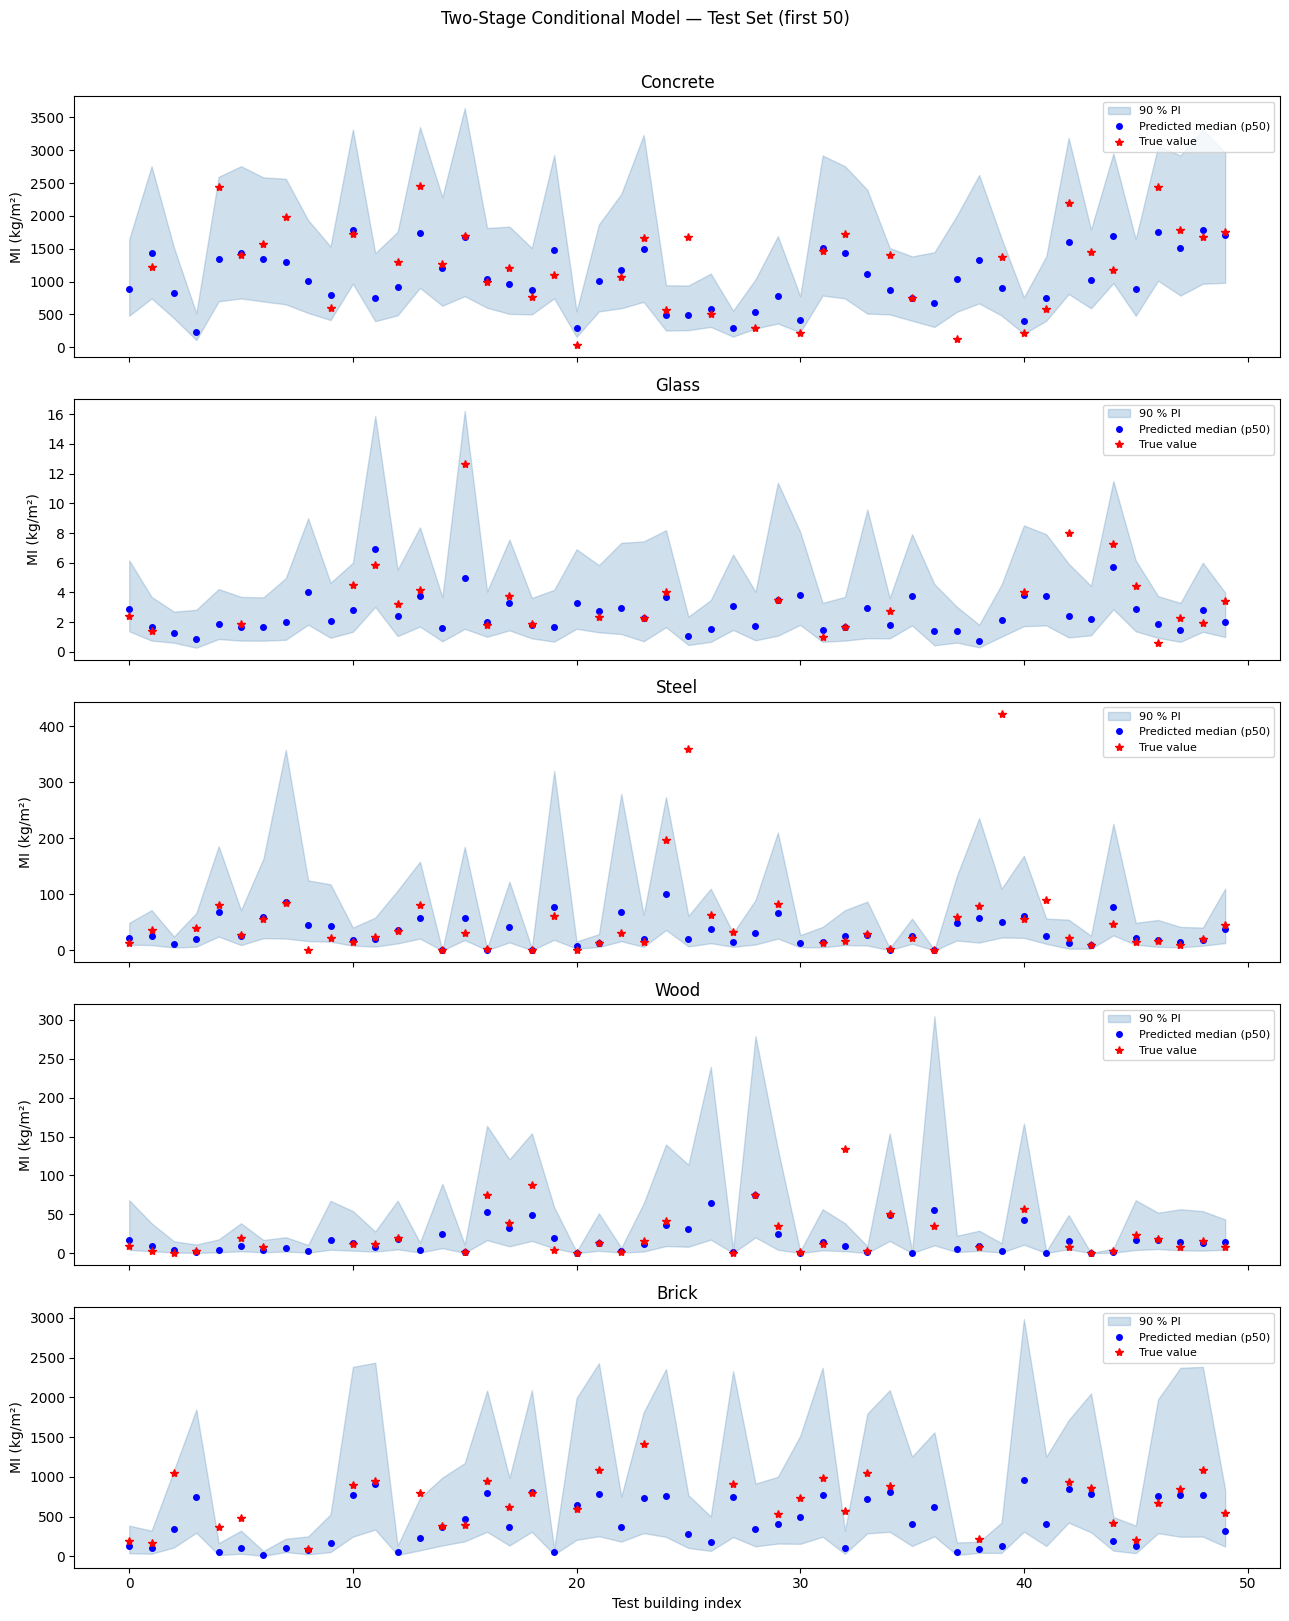

In [10]:
# ==========================================================
# Visualisation — predicted median + 90 % PI vs. true values
#                 (first 50 test-set buildings)
# ==========================================================

n_plot = 50
pred_plot = model.predict(data["X_test_proc"][:n_plot], data["groups_test"][:n_plot], alpha=0.10)

fig, axes = plt.subplots(5, 1, figsize=(13, 16), sharex=True)
x_idx = np.arange(n_plot)

for i, mat in enumerate(y_cols):
    ax = axes[i]
    y_true = data["y_test_df"][mat].iloc[:n_plot].to_numpy(dtype=float)
    observed = ~np.isnan(y_true)
    y_true_plot = y_true.copy()
    y_true_plot[~observed] = np.nan

    ax.fill_between(x_idx, pred_plot[mat]["p5"], pred_plot[mat]["p95"],
                    alpha=0.25, color="steelblue", label="90 % PI")
    ax.plot(x_idx, pred_plot[mat]["p50"], "bo", ms=4, label="Predicted median (p50)")
    ax.plot(x_idx, y_true_plot, "r*", ms=6, label="True value")
    ax.set_title(mat)
    ax.set_ylabel("MI (kg/m\u00b2)")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Test building index")
plt.suptitle("Two-Stage Conditional Model \u2014 Test Set (first 50)", y=1.01)
plt.tight_layout()
plt.show()


Presence-complete test rows: 135
  mean_vector_mae: 47.72
  cov_frobenius: 2.5459e+05
  corr_frobenius: 1.305
  kl_true_to_pred: 15.853
  kl_pred_to_true: 2.285


,material,true_mean,pred_mean,abs_mean_diff,true_std,pred_std,abs_std_diff
0,Concrete,1654.170734,1511.530983,142.639751,636.373380,395.927241,240.446139
1,Glass,2.922884,2.567914,0.354970,2.349873,1.203217,1.146656
2,Steel,25.643327,23.116766,2.526561,38.475675,16.098536,22.377139
3,Wood,23.603882,19.231961,4.371921,23.055424,15.412431,7.642993
4,Brick,682.684163,593.978381,88.705782,300.128005,252.049720,48.078286


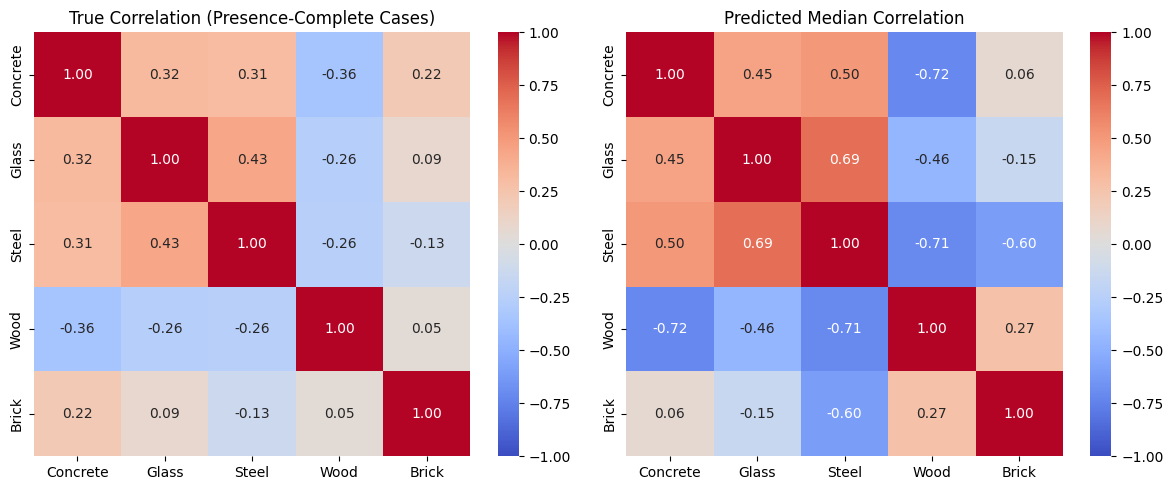

In [11]:
# ==========================================================
# Joint distribution evaluation
#   - Marginal moments (presence-complete rows)
#   - Material correlation heatmaps (true vs. predicted)
# ==========================================================

def _gaussian_kl(mu_p, cov_p, mu_q, cov_q, eps=1e-6):
    d = mu_p.shape[0]
    cov_p_r = cov_p + np.eye(d) * eps
    cov_q_r = cov_q + np.eye(d) * eps
    sp, ldp = np.linalg.slogdet(cov_p_r)
    sq, ldq = np.linalg.slogdet(cov_q_r)
    if sp <= 0 or sq <= 0:
        return np.nan
    inv_q = np.linalg.inv(cov_q_r)
    return 0.5 * (np.trace(inv_q @ cov_p_r)
                  + (mu_q - mu_p) @ inv_q @ (mu_q - mu_p)
                  - d + (ldq - ldp))


# Presence-complete rows: all 5 materials observed AND > 0.
# Matches the support used by JointDistributionModel.fit(); using y_mask.all()
# would include observed-as-zero rows whose covariance is not well-defined.
cc = (~np.isnan(data["y_test_raw"]) & (data["y_test_raw"] > 0)).all(axis=1)
y_tc = data["y_test_raw"][cc]
y_pc = model.stage2.predict(data["X_test_proc"][cc])

mu_t, mu_p   = y_tc.mean(0), y_pc.mean(0)
std_t, std_p = y_tc.std(0, ddof=1), y_pc.std(0, ddof=1)
cov_t  = np.cov(y_tc, rowvar=False)
cov_p  = np.cov(y_pc, rowvar=False)
corr_t = np.corrcoef(y_tc, rowvar=False)
corr_p = np.corrcoef(y_pc, rowvar=False)

print(f"Presence-complete test rows: {cc.sum()}")
stats_summary = {
    "mean_vector_mae":  float(np.mean(np.abs(mu_t - mu_p))),
    "cov_frobenius":    float(np.linalg.norm(cov_t - cov_p, ord="fro")),
    "corr_frobenius":   float(np.linalg.norm(corr_t - corr_p, ord="fro")),
    "kl_true_to_pred":  float(_gaussian_kl(mu_t, cov_t, mu_p, cov_p)),
    "kl_pred_to_true":  float(_gaussian_kl(mu_p, cov_p, mu_t, cov_t)),
}
for k, v in stats_summary.items():
    print(f"  {k}: {v:.5g}")

per_material = pd.DataFrame({
    "material": y_cols,
    "true_mean": mu_t, "pred_mean": mu_p, "abs_mean_diff": np.abs(mu_t - mu_p),
    "true_std":  std_t, "pred_std":  std_p, "abs_std_diff":  np.abs(std_t - std_p),
})
display(per_material)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, corr, title in zip(axes, [corr_t, corr_p],
                            ["True Correlation (Presence-Complete Cases)", "Predicted Median Correlation"]):
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                xticklabels=y_cols, yticklabels=y_cols, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()


In [12]:
# ==========================================================
# Save artefacts
# ==========================================================

# Rebind classes to the importable module path before pickling.
# This prevents __main__-scoped notebook classes from breaking joblib.load elsewhere.
import two_stage_model as tsm

model.__class__ = tsm.TwoStageConditionalModel
model.stage1.__class__ = tsm.MaterialOccurrenceModel
model.stage2.__class__ = tsm.MaterialIntensityModel
model.joint.__class__ = tsm.JointDistributionModel

joblib.dump(data["preprocessor"], "preprocessor.joblib")
joblib.dump(model, "model.joblib")

model_info = {
    "model_type":  "TwoStageConditionalModel",
    "stage1":      "XGBClassifier per-material (binary:logistic)",
    "stage2":      "XGBRegressor per-material in log-space (reg:squarederror)",
    "joint_layer": "MultivariateNormal with group-specific covariance",
    "group_cols":  list(GROUP_COLS),
    "y_cols":      y_cols,
    "X_cols":      X_cols,
    "stage1_xgb_params": model.stage1.xgb_params,
    "stage2_xgb_params": model.stage2.xgb_params,
}
with open("model_info.json", "w", encoding="utf-8") as f:
    json.dump(model_info, f, indent=2)

print("Saved: preprocessor.joblib,  model.joblib,  model_info.json")


Saved: preprocessor.joblib,  model.joblib,  model_info.json


In [13]:
# ==========================================================
# Validation 1 — Coverage, Interval Width, Median MAE
#   Evaluated on presence rows only (observed AND y > 0).
#   Coverage/MAE of the conditional intensity model against y=0 rows
#   is incoherent: those rows are Stage 1's responsibility.
# ==========================================================

coverage_results = []
for mat in y_cols:
    y_true = data["y_test_df"][mat].to_numpy(dtype=float)
    obs    = (~np.isnan(y_true)) & (y_true > 0)
    y_true = y_true[obs]
    q05 = pred_test[mat]["p5"][obs]
    q50 = pred_test[mat]["p50"][obs]
    q95 = pred_test[mat]["p95"][obs]
    widths = q95 - q05
    coverage_results.append({
        "material":     mat,
        "coverage_90":  round(float(np.mean((y_true >= q05) & (y_true <= q95))), 4),
        "mean_width":   round(float(widths.mean()), 2),
        "median_width": round(float(np.median(widths)), 2),
        "p50_mae":      round(mean_absolute_error(y_true, q50), 4),
    })

coverage_df = pd.DataFrame(coverage_results)
print("===== Coverage / Width / p50 MAE  (presence rows) =====")
print(coverage_df.to_string(index=False))


===== Coverage / Width / p50 MAE  (presence rows) =====
material  coverage_90  mean_width  median_width  p50_mae
Concrete       0.8114     1689.74       1905.71 470.0497
   Glass       0.8964        4.87          4.53   1.1424
   Steel       0.8902      101.15         70.51  19.1679
    Wood       0.8946       60.34         47.87   9.3956
   Brick       0.8592     1299.18       1217.57 218.0838


In [14]:
# ==========================================================
# Validation 5 — Baseline Comparison (training-set median)
#   Both model MAE and baseline MAE restricted to presence rows,
#   matching the support of the conditional Stage 2 regressor.
# ==========================================================

baseline_results = []
for i, mat in enumerate(y_cols):
    tr = data["y_train_raw"][:, i]
    # Presence-only baseline: median of positive training values
    tr = tr[(~np.isnan(tr)) & (tr > 0)]
    train_median = float(np.median(tr)) if len(tr) > 0 else 0.0

    y_true = data["y_test_df"][mat].to_numpy(dtype=float)
    obs    = (~np.isnan(y_true)) & (y_true > 0)
    y_true = y_true[obs]

    b_mae = mean_absolute_error(y_true, np.full_like(y_true, train_median))
    m_mae = coverage_df.loc[coverage_df["material"] == mat, "p50_mae"].values[0]

    baseline_results.append({
        "Material":        mat,
        "Baseline MAE":    round(b_mae, 2),
        "Model MAE":       round(float(m_mae), 2),
        "Improvement (%)": round((b_mae - m_mae) / b_mae * 100, 1) if b_mae > 0 else float("nan"),
    })

print("===== Baseline Comparison  (presence rows) =====")
print(pd.DataFrame(baseline_results).to_string(index=False))


===== Baseline Comparison  (presence rows) =====
Material  Baseline MAE  Model MAE  Improvement (%)
Concrete        662.18     470.05             29.0
   Glass          1.42       1.14             19.5
   Steel         30.40      19.17             36.9
    Wood         17.62       9.40             46.7
   Brick        301.84     218.08             27.7
